<a href="https://colab.research.google.com/github/bitriagaleonela40-cmd/housing-research/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
housing_df = pd.read_csv("/content/2022 LIHTC Full Tenant Data.csv")
housing_df


,Unnamed: 0,matching_hud_id,pin,state,propertyname,city,HH_RACE_WHITE_PCT,HH_RACE_BLACK_PCT,HH_RACE_AMINDALNAT_PCT,HH_RACE_ASIAN_PCT,...,UNITS_FRA_RPTD_GRT0_PCT,UNITS_FRA_SRC_PBRA_PCT,UNITS_FRA_SRC_S8_PCT,UNITS_FRA_SRC_PH_PCT,UNITS_FRA_SRC_HOME_PCT,UNITS_FRA_SRC_HCV_PCT,UNITS_FRA_SRC_PBV_PCT,UNITS_FRA_SRC_S521_PCT,UNITS_FRA_SRC_OTHER_PCT,UNITS_FRA_SRC_MSSNG_PCT
0,1,AKA20049041,AK-99-99,AK,BAYVIEW APTS. ASSOC. LP,SEWARD,91.300003,-4.0,-4.0,0.0,...,91.300003,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
1,2,AKA20049041,AK-99-99,AK,"CORDOVA MEWS ASSOC. OF CORDOVA, LLC",CORDOVA,46.299999,-4.0,-4.0,-4.0,...,97.599998,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
2,3,AKA20049041,AK-99-99,AK,EAGLE RIDGE OF PALMER,PALMER,87.500000,-4.0,-4.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,AKA20049041,AK-99-99,AK,"GATEWAY-SEWARD ASSOCIATES, LTD PTN",SEWARD,90.900002,-4.0,0.0,0.0,...,95.500000,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
4,5,AKA20049041,AK-99-99,AK,GLACIER PARK-KETCHIKAN ASSOC. LP,KETCHIKAN,76.099998,-4.0,-4.0,-4.0,...,97.800003,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38223,38224,NaN,NaN,WY,PINEWOOD APARTMENTS,MARBLETON,NaN,NaN,NaN,NaN,...,-4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38224,38225,NaN,NaN,NM,PASA TIEMPO,SANTE FE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38225,38226,NaN,NaN,SD,SICANGU VILLAGE ESTATES III,VALENTINE,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38226,38227,NaN,NaN,VA,BICKERSTAFF CROSSING,HENRICO,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
url = "https://github.com/frontiertechinstitute/datasets/raw/main/2022%20LIHTC%20Tenant%20Data/data/2022%20LIHTC%20Tenant%20Data%20by%20Property%20-%20HUD_ID.xlsx"
df = pd.read_excel(url)
df.head(5)
df[['matching_hud_id', 'pin', 'state', 'propertyname', 'city']]

,matching_hud_id,pin,state,propertyname,city
0,AKA20049041,AK-99-99,AK,BAYVIEW APTS. ASSOC. LP,SEWARD
1,AKA20049041,AK-99-99,AK,"CORDOVA MEWS ASSOC. OF CORDOVA, LLC",CORDOVA
2,AKA20049041,AK-99-99,AK,EAGLE RIDGE OF PALMER,PALMER
3,AKA20049041,AK-99-99,AK,"GATEWAY-SEWARD ASSOCIATES, LTD PTN",SEWARD
4,AKA20049041,AK-99-99,AK,GLACIER PARK-KETCHIKAN ASSOC. LP,KETCHIKAN
...,...,...,...,...,...
37081,WYA20160004,WY-14-286,WY,WOLF CREEK APARTMENTS,RIVERTON
37082,NaN,WY-07-150,WY,WOODRIDGE APARTMENTS,RIVERTON
37083,NaN,WY-05-128,WY,WYOMING NATIONAL APTS,CASPER
37084,WYA20080035,WY-06-425,WY,YELLOW CREEK VILLAGE,EVANSTON


Columms 6-13 come from table 4.
HH = House Hold Head. Each row represents one apartment complex

In [ ]:
#Create headofhouse data frame
headofhouse = housing_df[['state', 'propertyname' ,'city', 'HH_RACE_WHITE_PCT', 'HH_RACE_BLACK_PCT', 'HH_RACE_AMINDALNAT_PCT',
       'HH_RACE_ASIAN_PCT', 'HH_RACE_HAWAIIANPI_PCT', 'HH_RACE_OTHER_PCT',
       'HH_RACE_HISPANIC_PCT', 'HH_RACE_NR_PCT']]

#Renaming variables
headofhouse = headofhouse.rename(columns={"HH_RACE_WHITE_PCT": "White"})
headofhouse = headofhouse.rename(columns={"HH_RACE_BLACK_PCT": "BlackorAfricanAmerican"})
headofhouse = headofhouse.rename(columns={"HH_RACE_AMINDALNAT_PCT": "AmericanIndianorAlaskaNative"})
headofhouse = headofhouse.rename(columns={"HH_RACE_ASIAN_PCT": "Asian"})
headofhouse = headofhouse.rename(columns={"HH_RACE_HAWAIIANPI_PCT": "HawaiianorPacificIslander"})
headofhouse = headofhouse.rename(columns={"HH_RACE_OTHER_PCT": "OtherRace"})
headofhouse = headofhouse.rename(columns={"HH_RACE_HISPANIC_PCT": "Hispanic"})
headofhouse = headofhouse.rename(columns={"HH_RACE_NR_PCT": "Non_Reported"})

# Cleaning null values
for col in ['White', 'BlackorAfricanAmerican', 'AmericanIndianorAlaskaNative', 'Asian', 'HawaiianorPacificIslander', 'OtherRace', 'Hispanic', 'Non_Reported']:
    headofhouse[col] = headofhouse[col].replace(-4, np.nan)

headofhouse = headofhouse.dropna(axis = 0, how = 'any', subset = None)

Columns 14-20 come from Table 8

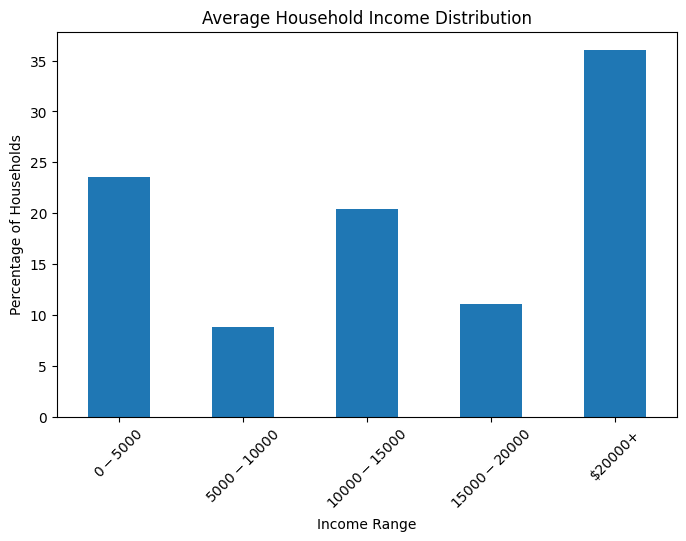

,state,propertyname,city,MedianIncome,IncomeReportedinPercent,$0-$5000,$5000-$10000,$10000-$15000,$15000-$20000,$20000+
30,AL,ALEXANDER VILLAGE APARTMENTS,ST FLORIAN,18129.0,100.000000,0.000000,0.0,33.299999,27.100000,39.599998
48,AL,ARBOURS AT DEMOPOLIS,DEMOPOLIS,9768.0,100.000000,37.700001,14.3,18.200001,15.600000,14.300000
59,AL,ASHTON WAY APARTMENTS,OPELIKA,16608.0,100.000000,0.000000,0.0,35.900002,31.299999,32.799999
68,AL,AZALEA POINTE APARTMENTS FKA VILLAGE GREEN APTS,MOBILE,10091.0,99.199997,39.500000,10.1,22.700001,17.600000,10.100000
92,AL,BRADBERRY POINTE,ALEXANDER CITY,18445.0,100.000000,0.000000,0.0,25.000000,30.400000,44.599998
...,...,...,...,...,...,...,...,...,...,...
36699,WI,WINDSOR COURT APARTMENT HOMES,MILWAUKEE,4860.0,97.300003,50.299999,9.8,18.900000,9.800000,11.200000
36984,WV,VISTA VIEW APARTMENTS,CHARLESTON,2249.0,99.000000,56.900002,6.6,18.799999,7.600000,10.100000
37013,WY,BEAVER CREEK III,ETHETE,53235.0,100.000000,0.000000,0.0,0.000000,0.000000,100.000000
37062,WY,HAWK'S POINT RESIDENCES,CHEYENNE,20121.0,100.000000,0.000000,0.0,26.900000,23.100000,50.000000


In [ ]:
#Create income data frame
household_income = housing_df[['state', 'propertyname' ,'city','MEDIAN_INC', 'INCOME_REPORTED_PCT', 'UNITS_INC_0_5K_PCT',
       'UNITS_INC_5K_10K_PCT', 'UNITS_INC_10K_15K_PCT', 'UNITS_INC_15_20K_PCT',
       'UNITS_INC_GRT_20K_PCT']]

#Rename varibles
household_income = household_income.rename(columns={"MEDIAN_INC": "MedianIncome"})
household_income = household_income.rename(columns={"INCOME_REPORTED_PCT": "IncomeReportedinPercent"})
household_income = household_income.rename(columns={"UNITS_INC_0_5K_PCT": "$0-$5000"})
household_income = household_income.rename(columns={"UNITS_INC_5K_10K_PCT": "$5000-$10000"})
household_income = household_income.rename(columns={"UNITS_INC_10K_15K_PCT": "$10000-$15000"})
household_income = household_income.rename(columns={"UNITS_INC_15_20K_PCT": "$15000-$20000"})
household_income = household_income.rename(columns={"UNITS_INC_GRT_20K_PCT": "$20000+"})

# Cleaning null values
for col in ['MedianIncome', 'IncomeReportedinPercent', '$0-$5000', '$5000-$10000', '$10000-$15000', '$15000-$20000', '$20000+']:
    household_income[col] = household_income[col].replace(-4, np.nan)

household_income = household_income.dropna(axis = 0, how = 'any', subset = None)
household_income

#Data Visualization
income_columns = [
    '$0-$5000',
    '$5000-$10000',
    '$10000-$15000',
    '$15000-$20000',
    '$20000+'
]

household_income[income_columns].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Household Income Distribution")
plt.ylabel("Percentage of Households")
plt.xlabel("Income Range")
plt.xticks(rotation=45)
plt.show()
household_income

 Columns 21-26 come from table 9

In [ ]:
#Create income relative to Area Median Income
IncometoAmi = housing_df[['state', 'propertyname' ,'city','UNITS_I_IL_IR_0_PCT', 'UNITS_I_IL_IR_0_30_PCT',
       'UNITS_I_IL_IR_30_40_PCT', 'UNITS_I_IL_IR_40_50_PCT',
       'UNITS_I_IL_IR_50_60_PCT', 'UNITS_I_IL_IR_GT60_PCT']]
#Rename variables
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_0_PCT": "0%"})
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_0_30_PCT": "0-30%"})
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_30_40_PCT": "30-40%"})
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_40_50_PCT": "40-50%"})
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_50_60_PCT": "50-60%"})
IncometoAmi = IncometoAmi.rename(columns={"UNITS_I_IL_IR_GT60_PCT": "60%+"})

# Cleaning null values
for col in ['0%', '0-30%', '30-40%', '40-50%', '50-60%', '60%+']:
    IncometoAmi[col] = IncometoAmi[col].replace(-4, np.nan)

IncometoAmi = IncometoAmi.dropna(axis = 0, how = 'any', subset = None)

IncometoAmi

,state,propertyname,city,0%,0-30%,30-40%,40-50%,50-60%,60%+
22,AL,ABBINGTON SUMMIT POINTE,IRONDALE,0.0,0.000000,0.0,0.0,0.0,0.0
23,AL,ADAMS CROSSINGS F/K/A BROWNSTONE APARTMENTS,BOAZ,0.0,0.000000,0.0,0.0,0.0,0.0
24,AL,ADAMS RIDGE APARTMENTS,UNION SPRINGS,0.0,0.000000,0.0,0.0,0.0,0.0
25,AL,ADDISON WAY,SELMA,0.0,0.000000,0.0,0.0,0.0,0.0
26,AL,AHEPA 310 APARTMENTS,MOBILE,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
38188,WA,WINTER HEIGHTS,SPOKANE,0.0,32.200001,12.2,20.0,16.5,19.1
38204,WI,PLEASANT VIEW APTS II,RACINE,0.0,0.000000,0.0,0.0,0.0,0.0
38206,WI,ST CROIX FALLS TOWNHOMES,ST CROIX FALLS,0.0,0.000000,0.0,0.0,0.0,0.0
38207,WI,THE PARKVIEW (PHASE II),TN OF CALEDONIA,0.0,0.000000,0.0,0.0,0.0,0.0


Columns 27-33 come from Table 10

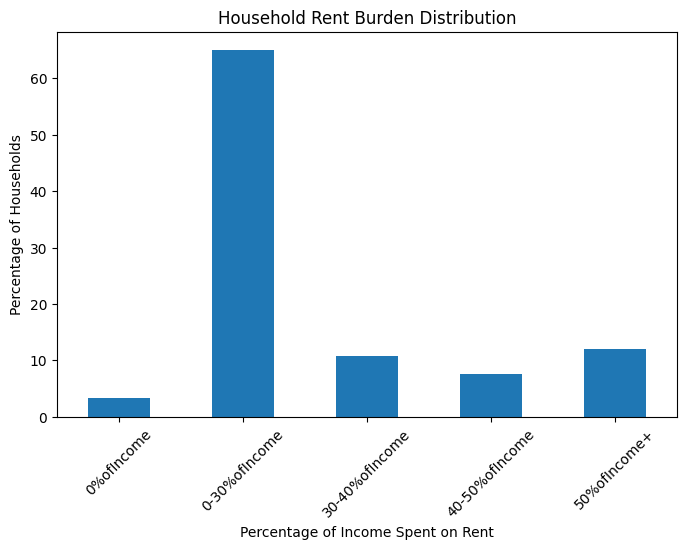

In [ ]:
#Create data frame
rentBurden = housing_df[['state', 'propertyname' ,'city','UNITS_INC_RNT_RPTD_PCT', 'UNITS_INC_RNT_0_PCT',
       'UNITS_INC_RNT_0_30_PCT', 'UNITS_INC_RNT_30_40_PCT',
       'UNITS_INC_RNT_40_50_PCT', 'UNITS_INC_RNT_GRT_50_PCT',
       'UNITS_INC_RNT_NOT_CAL_PCT']]

#Rename variables
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_RPTD_PCT": "IncomeAndRentRprt"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_0_PCT": "0%ofIncome"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_0_30_PCT": "0-30%ofIncome"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_30_40_PCT": "30-40%ofIncome"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_40_50_PCT": "40-50%ofIncome"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_GRT_50_PCT": "50%ofIncome+"})
rentBurden = rentBurden.rename(columns={"UNITS_INC_RNT_NOT_CAL_PCT": "NotCalculated"})

# Cleaning null values
for col in ['IncomeAndRentRprt', '0%ofIncome', '0-30%ofIncome', '30-40%ofIncome', '40-50%ofIncome', '50%ofIncome+', 'NotCalculated']:
    rentBurden[col] = rentBurden[col].replace(-4, np.nan)

rentBurden = rentBurden.dropna(axis = 0, how = 'any', subset = None)

rentBurden

#Data Visualization
rent_columns = [
    '0%ofIncome',
    '0-30%ofIncome',
    '30-40%ofIncome',
    '40-50%ofIncome',
    '50%ofIncome+'
]

rentBurden[rent_columns].mean().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Household Rent Burden Distribution")
plt.ylabel("Percentage of Households")
plt.xlabel("Percentage of Income Spent on Rent")
plt.xticks(rotation=45)
plt.show()

Columns 34-36 come from Table 11

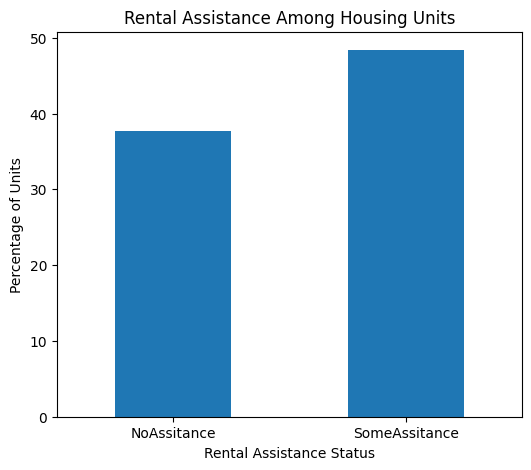

,state,propertyname,city,Missing,NoAssitance,SomeAssitance
1,AK,"CORDOVA MEWS ASSOC. OF CORDOVA, LLC",CORDOVA,0.0,0.000000,100.000000
5,AK,HAMPSTEAD HEATH,ANCHORAGE,0.0,58.099998,41.900002
9,AK,"MILL BAY TOWNHOMES, LLC",KODIAK,0.0,69.199997,30.799999
10,AK,MLH MANOR,FAIRBANKS,0.0,45.700001,54.299999
12,AK,NORTHWARD BUILDING,FAIRBANKS,0.0,73.300003,26.700001
...,...,...,...,...,...,...
38199,WI,MADISON ON BROADWAY,MADISON,0.0,60.000000,40.000000
38203,WI,PARKVIEW COMMONS,SOMERS,0.0,80.199997,19.799999
38205,WI,RED CLIFF REHAB II,RUSSELL,0.0,100.000000,0.000000
38210,WV,GREENE GABLES,SHORT GAP,0.0,77.099998,22.900000


In [ ]:
#Create date frame
rentalAsssitance =housing_df[['state', 'propertyname' ,'city','UNITS_RNTASSTNCE_MSNG_PCT', 'UNITS_RNTASSTNCE_RPTD_0_PCT',
       'UNITS_RNTASSTNCE_RPTD_GRT0_PCT']]

#Rename variables
rentalAsssitance = rentalAsssitance.rename(columns={"UNITS_RNTASSTNCE_MSNG_PCT": "Missing"})
rentalAsssitance = rentalAsssitance.rename(columns={"UNITS_RNTASSTNCE_RPTD_0_PCT": "NoAssitance"})
rentalAsssitance = rentalAsssitance.rename(columns={"UNITS_RNTASSTNCE_RPTD_GRT0_PCT": "SomeAssitance"})

# Cleaning null values
for col in ['Missing', 'NoAssitance', 'SomeAssitance']:
    rentalAsssitance[col] = rentalAsssitance[col].replace(-4, np.nan)

rentalAsssitance = rentalAsssitance.dropna(axis = 0, how = 'any', subset = None)

rentalAsssitance

#Data Visualization
assistance_columns = [
    'NoAssitance',
    'SomeAssitance'
]

rentalAsssitance[assistance_columns].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Rental Assistance Among Housing Units")
plt.ylabel("Percentage of Units")
plt.xlabel("Rental Assistance Status")
plt.xticks(rotation=0)
plt.show()
rentalAsssitance

Columns 37-46 come from Table 12

In [ ]:
#Create data frame
federalAssitenceSource = housing_df[['state', 'propertyname' ,'city','UNITS_FRA_RPTD_GRT0_PCT',
       'UNITS_FRA_SRC_PBRA_PCT', 'UNITS_FRA_SRC_S8_PCT',
       'UNITS_FRA_SRC_PH_PCT', 'UNITS_FRA_SRC_HOME_PCT',
       'UNITS_FRA_SRC_HCV_PCT', 'UNITS_FRA_SRC_PBV_PCT',
       'UNITS_FRA_SRC_S521_PCT', 'UNITS_FRA_SRC_OTHER_PCT',
       'UNITS_FRA_SRC_MSSNG_PCT']]

#Rename variables
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_RPTD_GRT0_PCT": "%withfederalAssitanceReported"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_PBRA_PCT": "Project-BasedRental"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_S8_PCT": "Section8"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_PH_PCT": "PublicHousing"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_HOME_PCT": "HOMEInvestment"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_HCV_PCT": "HousingChoiceVoucher"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_PBV_PCT": "ProjectBasedVoucher"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_S521_PCT": "Section521"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_OTHER_PCT": "Other"})
federalAssitenceSource = federalAssitenceSource.rename(columns={"UNITS_FRA_SRC_MSSNG_PCT": "Missing"})

# Cleaning null values
for col in ["%withfederalAssitanceReported", "Project-BasedRental", "Section8", "PublicHousing", "HOMEInvestment", "HousingChoiceVoucher", "ProjectBasedVoucher", "Section521", "Other", "Missing"]:
    federalAssitenceSource[col] = federalAssitenceSource[col].replace(-4, np.nan)

federalAssitenceSource = federalAssitenceSource.dropna(axis = 0, how = 'any', subset = None)

federalAssitenceSource

,state,propertyname,city,%withfederalAssitanceReported,Project-BasedRental,Section8,PublicHousing,HOMEInvestment,HousingChoiceVoucher,ProjectBasedVoucher,Section521,Other,Missing
0,AK,BAYVIEW APTS. ASSOC. LP,SEWARD,91.300003,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
1,AK,"CORDOVA MEWS ASSOC. OF CORDOVA, LLC",CORDOVA,97.599998,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
2,AK,EAGLE RIDGE OF PALMER,PALMER,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AK,"GATEWAY-SEWARD ASSOCIATES, LTD PTN",SEWARD,95.500000,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
4,AK,GLACIER PARK-KETCHIKAN ASSOC. LP,KETCHIKAN,97.800003,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
38206,WI,ST CROIX FALLS TOWNHOMES,ST CROIX FALLS,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38208,WV,ASHLEY MANOR APARTMENTS,RIPLEY,92.300003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
38209,WV,DUTCH RIDGE,DAVISVILLE,95.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
38210,WV,GREENE GABLES,SHORT GAP,22.900000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0


Exploring Question Number 1: Do LIHTC properties with rental assitence have lower rent burden?

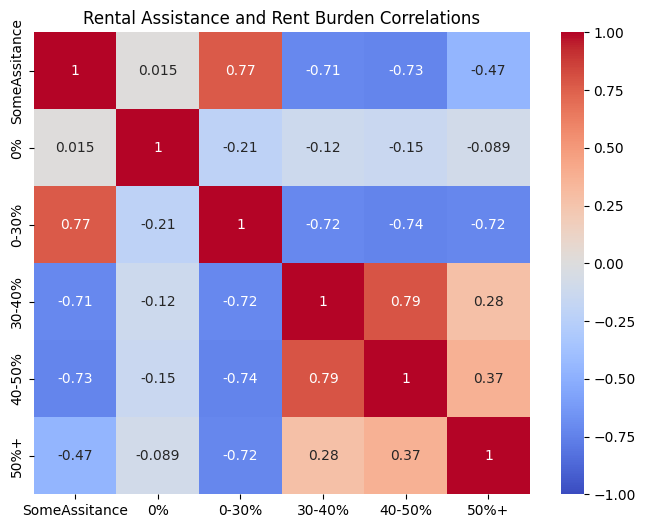

,state,propertyname,city,NoAssitance,SomeAssitance,0%,0-30%,30-40%,40-50%,50%+
26,AL,AHEPA 310 APARTMENTS,MOBILE,0.0,100.0,0.000000,100.000000,0.0,0.0,0.000000
41,AL,APARTMENTS AT RUSSEL ERSKINE FKA RUSSEL ERSKIN...,HUNTSVILLE,0.0,100.0,0.000000,100.000000,0.0,0.0,0.000000
91,AL,BONAIRE VILLAS,PINE HILL,0.0,100.0,0.000000,100.000000,0.0,0.0,0.000000
93,AL,BRADLEY PARK APARTMENTS,ATTALLA,0.0,100.0,55.900002,44.099998,0.0,0.0,0.000000
100,AL,BRISTOL DOWNS APARTMENTS FKA FIELDCREST,MONTGOMERY,57.5,42.5,10.200000,48.700001,12.8,6.6,21.700001
...,...,...,...,...,...,...,...,...,...,...
36939,WV,RYAN VILLAGE,PRINCETON,0.0,100.0,0.000000,100.000000,0.0,0.0,0.000000
36948,WV,SMITHFIELD ESTATES,BUFFALO,0.0,100.0,0.000000,100.000000,0.0,0.0,0.000000
37004,WY,AIRPORT ROAD PROJECT,RIVERTON,100.0,0.0,0.000000,100.000000,0.0,0.0,0.000000
37012,WY,BEAVER CREEK HOUSING,RIVERTON,100.0,0.0,0.000000,100.000000,0.0,0.0,0.000000


In [ ]:
#Create a data frame that includes: rental assitance, rent burden, and city, property name, and state.

Question_one = housing_df[['state', 'propertyname' ,'city', 'UNITS_RNTASSTNCE_RPTD_0_PCT',
       'UNITS_RNTASSTNCE_RPTD_GRT0_PCT', 'UNITS_INC_RNT_0_PCT',
       'UNITS_INC_RNT_0_30_PCT', 'UNITS_INC_RNT_30_40_PCT',
       'UNITS_INC_RNT_40_50_PCT', 'UNITS_INC_RNT_GRT_50_PCT',
       ]]

#Rename varibles (Assitance)
Question_one = Question_one.rename(columns={"UNITS_RNTASSTNCE_RPTD_0_PCT": "NoAssitance"})
Question_one = Question_one.rename(columns={"UNITS_RNTASSTNCE_RPTD_GRT0_PCT": "SomeAssitance"})
#(Rent Burden)
#Percent of units where gross rent is % percent of annual household income.
Question_one = Question_one.rename(columns={"UNITS_INC_RNT_0_PCT": "0%"}) #% of units in x propertiy have their gross rent = 0% of annual household income
Question_one = Question_one.rename(columns={"UNITS_INC_RNT_0_30_PCT": "0-30%"})
Question_one = Question_one.rename(columns={"UNITS_INC_RNT_30_40_PCT": "30-40%"})
Question_one = Question_one.rename(columns={"UNITS_INC_RNT_40_50_PCT": "40-50%"})
Question_one = Question_one.rename(columns={"UNITS_INC_RNT_GRT_50_PCT": "50%+"})


#Drop null values
for col in ['state', 'propertyname', 'city', 'NoAssitance', 'SomeAssitance', '0%', '0-30%','30-40%', '40-50%', '50%+']:
  Question_one[col] = Question_one[col].replace(-4, np.nan)

Question_one = Question_one.dropna(axis = 0, how = 'any', subset = None)

#Data visualisation #Need to change to bar graph before determining what statistical analysis I should use.
cols = [
    'SomeAssitance',
    '0%',
    '0-30%',
    '30-40%',
    '40-50%',
    '50%+'
]

corr = Question_one[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Rental Assistance and Rent Burden Correlations")
plt.show()
Question_one

Perfoming a Statistical Analysis on Question 1: **Do LIHTC properties with more retal assitence have lower rent burden?**

In [ ]:
#Statistical Analysis 1:

Exploring Question Number 2: Do LITCH properties with more rental assitance have a lower median income?

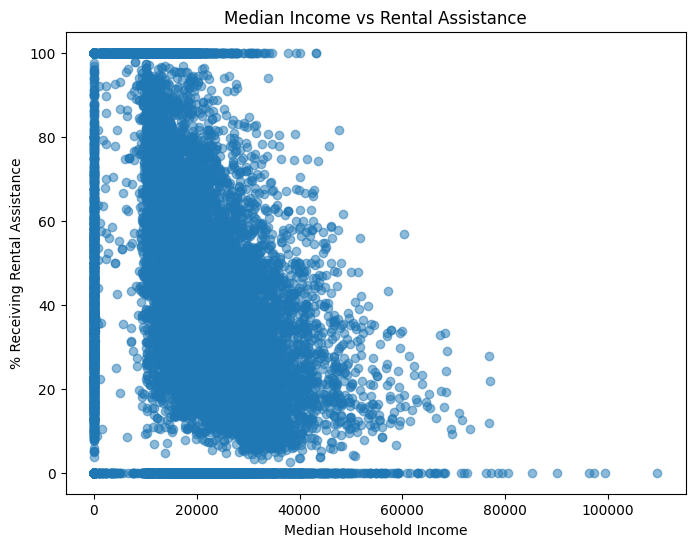

,state,propertyname,city,MedianIncome,NoAssitance,SomeAssitance
1,AK,"CORDOVA MEWS ASSOC. OF CORDOVA, LLC",CORDOVA,21922.0,0.000000,100.000000
5,AK,HAMPSTEAD HEATH,ANCHORAGE,36761.0,58.099998,41.900002
9,AK,"MILL BAY TOWNHOMES, LLC",KODIAK,44154.0,69.199997,30.799999
10,AK,MLH MANOR,FAIRBANKS,18733.0,45.700001,54.299999
12,AK,NORTHWARD BUILDING,FAIRBANKS,21864.0,73.300003,26.700001
...,...,...,...,...,...,...
37116,WY,TIGEE VILLAGE,FORT WASHAKIE,24960.0,100.000000,0.000000
37117,WY,TOWNHOUSE APARTMENTS,SHERIDAN,34800.0,100.000000,0.000000
37121,WY,WIND RIVER APARTMENTS,DOUGLAS,29094.0,100.000000,0.000000
37122,WY,WINDRIDGE APARTMENTS,GILLETTE,29470.0,73.900002,26.100000


In [8]:
#Create a data frame with household income and rental assitance
Question_two = housing_df[['state', 'propertyname' ,'city', 'MEDIAN_INC', 'UNITS_RNTASSTNCE_RPTD_0_PCT',
       'UNITS_RNTASSTNCE_RPTD_GRT0_PCT', ]]
#Rename variables
Question_two = Question_two.rename(columns={"MEDIAN_INC": "MedianIncome"})
Question_two = Question_two.rename(columns={"UNITS_RNTASSTNCE_RPTD_0_PCT": "NoAssitance"})
Question_two = Question_two.rename(columns={"UNITS_RNTASSTNCE_RPTD_GRT0_PCT": "SomeAssitance"})

#Clean null values
for col in ['MedianIncome',"NoAssitance", "SomeAssitance"]:
  Question_two[col] = Question_two[col].replace(-4, np.nan)

Question_two = Question_two.dropna(axis = 0, how = 'any', subset = None)

#Data Visualization
plt.figure(figsize=(8,6))

plt.scatter(Question_two['MedianIncome'],
            Question_two['SomeAssitance'],
            alpha=0.5)

plt.xlabel("Median Household Income")
plt.ylabel("% Receiving Rental Assistance")
plt.title("Median Income vs Rental Assistance")

plt.show()
Question_two

Perfoming a Statistical Analysis on Question 2: **Do LITCH properties with  rental assitance have a lower median income?**

**Null Hypothesis**: Properties with rental assitance have a lower median income

**Alternative Hypothesi**s: Properties with rental assitance do not have a lower median income.

In [17]:
#Statistical Analysis 2
#Linear Regression
#Imports
!pip install pandas
import pandas as pd

!pip install matplotlib
import matplotlib.pyplot as plt

!pip install scikit-learn
from sklearn import datasets, model_selection
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression

#Decide variables
features = Question_two['SomeAssitance']
labels = Question_two['MedianIncome']

#Split data into training and test sets

X_train, X_test, y_train, y_test = model_selection.train_test_split(
features, labels, test_size=0.2)

#Initiante model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

#Fit model
lr_model.fit(X_train, y_train)

#Test model on test data
pred = lr_model.predict(X_test)





#Evaluate model
print('mean squared: ', mean_squared_error(y_test, pred))

print('mean absolute: ', mean_absolute_error(y_test, pred))

print('R2 score: ', r2_score(y_test, pred))

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

Exploring Research Question: **How does rental assistance in LIHTC properties translate into resident income levels and rent burdens?**

In [ ]:
#Create final data frame that inclues: rental assitance, median income, and rent burden.


Perfoming a Statistical Analysis on Research Question: **How does rental assistance in LIHTC properties translate into resident income levels and rent burdens?**


In [ ]:
#Stasticical Analysis 3 (Research Question):